In [ ]:
import subprocess
import sys
import re
import os
sys.path.insert(0, os.path.abspath('../../../../'))
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import seaborn.objects as so
import warnings
warnings.filterwarnings("ignore")
import multiprocessing as mp
import pandas as pd
import numpy as np
import astropy.units as u
from astropy.constants import G
from numpy import pi
import spacehub_calc as sc
import matplotlib.animation as animation
import time
import itertools
from tqdm.notebook import tqdm

In [2]:
m1 = 1.0 #Solar Mass
q = 10.0 #"mass ratio"
sma = 0.1 #AU
ecc = 0.1 #eccentricity
incl = 30 #inclination deg
loa = 45 #longitude of ascending node deg
aop = 60 #argument of periapsis deg
ta = 90 #true anom deg
#outFile = "test/nick_test/KeplerSimpleGen.dat"

In [ ]:
compile = "g++ -std=c++17 -O3 -pthread KeplerSimple.cpp -o KeplerSimple"

compstd = subprocess.run(compile, shell=True, capture_output=True, text=True, timeout=60)

clearcmd = "rm ../archived/KeplerSweepTest/*"
try:
    clearstd = subprocess.run(clearcmd, shell=True, capture_output=True, text=True, timeout=60)
except Exception as e:
    print("not cleared")

def runsim(m1=1.0, q=10.0, sma=0.1, ecc=0.1, incl=30, loa=45, aop=60, ta=90, atol=0):
    # USES MODIFIED VERSION WITH NO OUTPUT. ORIGINAL FILE FOR INDIVIDUAL CHECKING IS KeplerSimple.cpp
    
    outcome = "n/a"
    otherstr = ""
    
    outstr = f"../archived/KeplerSweepTest/1-{q:.2e}-{sma:.2e}-{ecc:2f}-{atol:.2e}.dat"
    run = f"./KeplerSimple -m1 {m1:.5f} -q {q:.5f} -sma {sma:.5f} -ecc {ecc:.5f} -inc {incl} -lan {loa} -aop {aop} -ta {ta} -atol {atol} -out {outstr}"

    t0 = time.perf_counter()
    try:
        runstd = subprocess.run(run, shell=True, capture_output=True, text=True, timeout=90)
        if runstd.returncode == 0:
            
            outcome = "success"
        else:
            #print(f"Runtime Error:{runstd.stderr}\n")
            #print(f"stdout: {runstd.stdout}\n")
            otherstr = f"stderr: {runstd.stderr} \n stdout: {runstd.stdout}"
            outcome = "runtime_err"
    except subprocess.TimeoutExpired as toerr:
        
        outcome = "timeout"
    except Exception as e:
        print("non-timeout exception!\n")
        outcome = "error"
         
    dtime = time.perf_counter() - t0
    #print(f"Orbit analyzed in: {dtime:.4f}s\n")

    nr = {}
    nr["res"] = outcome
    nr["m1"] = m1 
    nr["q"] = q
    nr["sma"] = sma
    nr["ecc"] = ecc
    nr["incl"] = incl
    nr["loa"] = loa 
    nr["aop"] = aop
    nr["ta"] = ta 
    nr["atol"] = atol
    nr["runtime"] = dtime
    nr["other"] = otherstr
    nr["outfile"] = outstr
    nr["runstr"] = run

    return nr

In [4]:
q_range = [1,10,100]
sma_range = [100, 1000, 10000] #max iteration reached error for sma=1000
ecc_range = [0.009, 0.9, 0.99]
atol = [0, 1e-12, 1e-10, 1e-6, 1e-3, 1e-1, 1]

# Generate all parameter combinations
param_combinations = list(itertools.product(q_range, sma_range, ecc_range, atol))

# Wrapper function for parallel execution
def run_single_simulation(params):
    q_val, sma_val, ecc_val, atol_val = params
    
    return runsim(q=q_val, sma=sma_val, ecc=ecc_val, atol=atol_val)

# Run simulations in parallel
with mp.Pool(processes=mp.cpu_count()-1) as pool:
    all_results = list(tqdm(
        pool.imap(run_single_simulation, param_combinations),
        total=len(param_combinations),
        desc="Simulations",
        unit="sim"
    ))

results_df = pd.DataFrame(all_results)

Simulations:   0%|          | 0/189 [00:00<?, ?sim/s]

In [8]:
results_df[results_df["res"]=="error"]

,res,m1,q,sma,ecc,incl,loa,aop,ta,atol,runtime,other,outfile,runstr


<Axes: xlabel='sma', ylabel='runtime'>

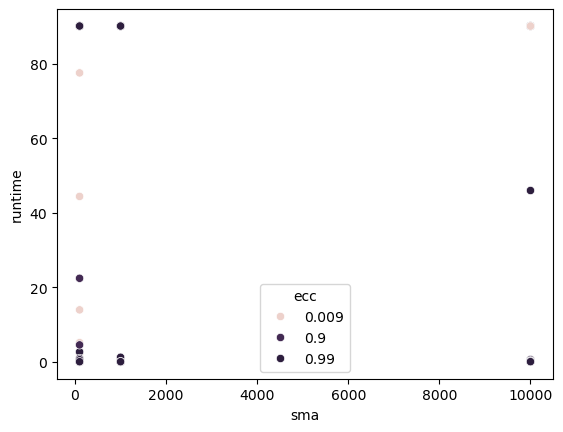

In [6]:
sns.scatterplot(data=results_df, x="sma", y="runtime", hue="ecc")

In [ ]:
results_df.to_csv("../../../../misc_output/KSRes.csv")

For viewing individual results (replace idx with the index of the specific simulation in results_df)

In [ ]:
idx = 27
outFile = results_df.loc[idx, :]["outfile"]
outFile

'test/nick_test/KeplerSweepTest/1-2.00e+00-1.00e+01-0.500000.dat'

In [ ]:
t0 = time.perf_counter()
orb = sc.TwoBodyOrbit(outFile, i=0, j=1)
dtime = time.perf_counter() - t0
print(f"Orbit analyzed in: {dtime:.4f} s")

load data complete
Determining timesteps...
Calculating orbital state vectors...
Calculating scalar orbital elements...
Calculated c0 values are within 10.46 of constant (maximum - minimum)
Done
Orbit analyzed in: 0.1209 s


(<Figure size 1000x1000 with 4 Axes>,
 [<Axes: title={'center': 'Separation'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$||R||$ (AU)'>,
  <Axes: title={'center': 'Eccentricity'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$e$'>,
  <Axes: title={'center': 'Argument of Periapsis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$\\omega$ (deg)'>,
  <Axes: title={'center': 'Semi-major Axis'}, xlabel='$yr (2\\pi)^{-1}$', ylabel='$a$ (AU)'>])

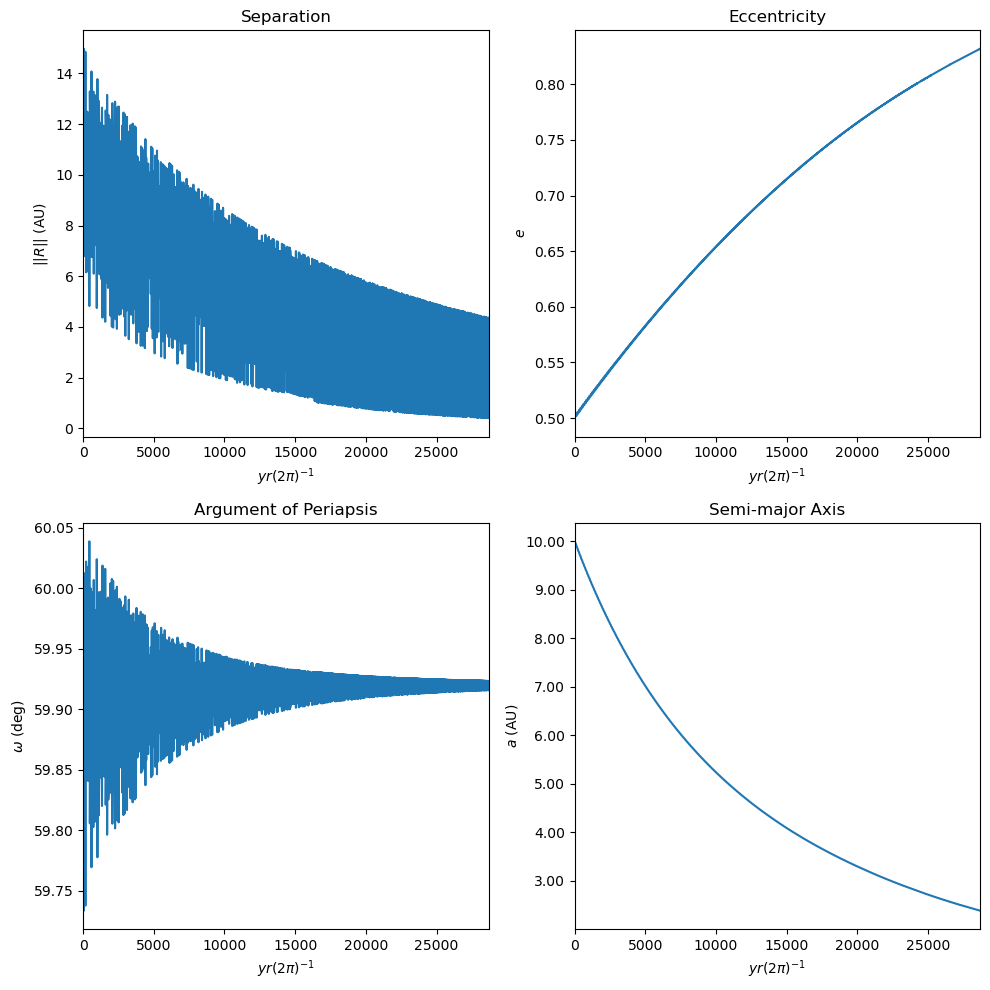

In [ ]:
orb.plot_keplerian_evolution(plots=('R','e','omega','a'), ylim=False, figsize=(10,10))

<Axes: >

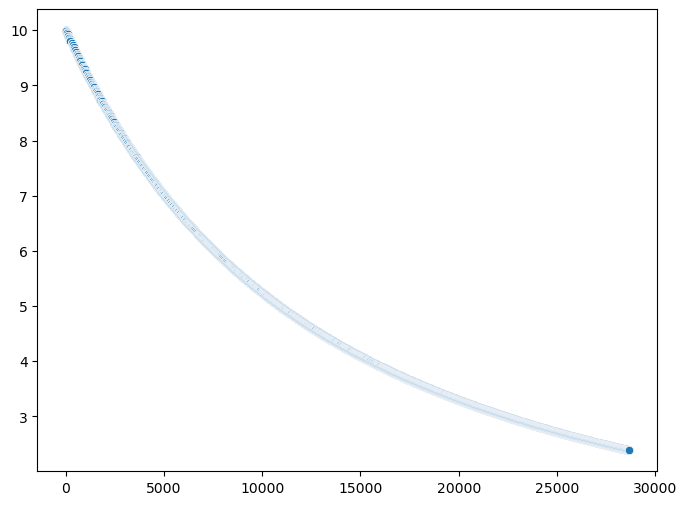

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.scatterplot(x=orb.time, y=orb.semiMajorAxis, ax=ax)